In [ ]:
# 1차원 벡터로 변환해 주었으니까 CNN 사용하기 힘듦, MLP 사용하기
# softmax, categorical crossentropy 사용할 거니까 output 정수로 변환하고, 원핫 인코딩 진행하기
# 스케일러 적용하기, standardscaler, minmax scaler 중에서 min max를 사용하는 게 더 좋을듯
# MLP 모델 학습
# 그래프 시각화

In [1]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


5


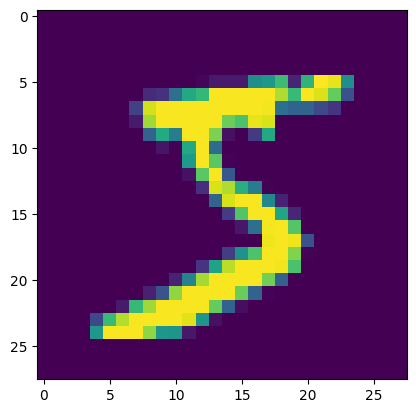

In [2]:
import matplotlib.pyplot as plt
print(y_train[0])
plt.imshow(x_train[0])
plt.show()

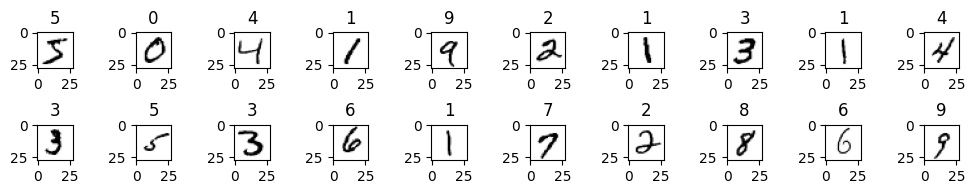

In [3]:
fig, axs = plt.subplots(nrows=2, ncols=10, layout='tight', figsize=(10,2))
for i in range(20):
  axs.flat[i].set_title(y_train[i])
  axs.flat[i].imshow(x_train[i], cmap='Greys')
plt.show()

In [4]:
import numpy as np
np.min(x_train), np.max(x_train)

(np.uint8(0), np.uint8(255))

In [5]:
x_train_1d = x_train.reshape((60000,-1)) / 255
x_test_1d = x_test.reshape((10000,-1)) / 255
print(x_train_1d.shape, x_test_1d.shape, np.max(x_train_1d))

(60000, 784) (10000, 784) 1.0


In [8]:
# 1차원 벡터로 변환해 주었으니까 CNN 사용하기 힘듦, MLP 사용하기
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
# 1. softmax, categorical crossentropy 사용할 거니까 output 정수로 변환하고, 원핫 인코딩 진행하기
# 문자열 레이블을 정수로 변환
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)  # 문자열 → 정수
y_test_int = le.transform(y_test)

# 정수 레이블 → 원-핫 인코딩
y_train_encoded = to_categorical(y_train_int)
y_test_encoded = to_categorical(y_test_int)

# 스케일러 적용하기, standardscaler, minmax scaler 중에서 standardscaler를 사용하는 게 더 좋을듯
scaler = StandardScaler()
scaler.fit(x_train_1d)
x_train_zs = scaler.transform(x_train_1d)
x_test_zs = scaler.transform(x_test_1d)
print(x_train_zs.shape, y_test.shape)

(60000, 784) (10000,)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,874 (1.79 MB)

 Trainable params: 468,874 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9038 - loss: 0.3370 - val_accuracy: 0.9611 - val_loss: 0.1439
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9720 - loss: 0.0948 - val_accuracy: 0.9683 - val_loss: 0.1288
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9778 - loss: 0.0748 - val_accuracy: 0.9691 - val_loss: 0.1327
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9819 - loss: 0.0562 - val_accuracy: 0.9674 - val_loss: 0.1355
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9854 - loss: 0.0504 - val_accuracy: 0.9673 - val_loss: 0.1469
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9874 - loss: 0.0440 - val_accuracy: 0.9717 - val_loss: 0.1622
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9891 - loss: 0.0391 - val_accuracy: 0.9715 - val_loss: 0.2010
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9899 - loss: 0.0363 - 

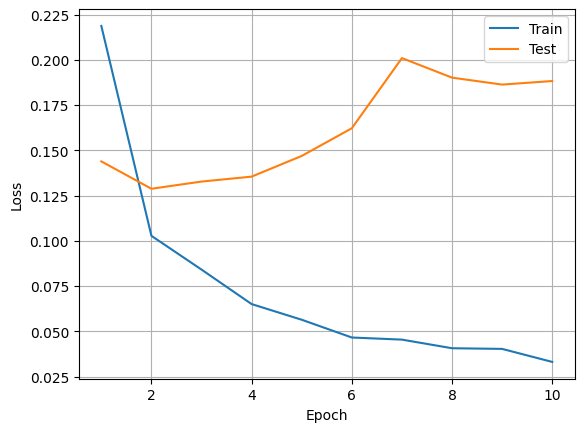

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt

# MLP 모델 학습
# 그래프 시각화
bc_nn = Sequential()
bc_nn.add(Input(shape=(784,)))
bc_nn.add(Dense(512, activation='relu'))
bc_nn.add(Dense(128, activation='relu'))
bc_nn.add(Dense(10, activation='softmax'))
bc_nn.summary()
bc_nn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = bc_nn.fit(x_train_zs, y_train_encoded,
                 validation_data=(x_test_zs, y_test_encoded),
                 epochs=10)

plt.plot(range(1,11), hist.history['loss'], label='Train')
plt.plot(range(1,11), hist.history['val_loss'], label='Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()    # 격자무늬 설정
plt.legend()  # 범례 표시
plt.show()

In [12]:
from sklearn.datasets import fetch_lfw_people
lfw_people = fetch_lfw_people(min_faces_per_person=100)
print(lfw_people.images.shape, lfw_people.data.shape)
print(lfw_people.target_names)

(1140, 62, 47) (1140, 2914)
['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']


In [13]:
np.min(lfw_people.images), np.max(lfw_people.images)

(np.float32(0.0), np.float32(1.0))

In [14]:
print(lfw_people.images[0])

[[0.32026145 0.34771243 0.26013073 ... 0.4143791  0.39215687 0.351634  ]
 [0.3503268  0.39346406 0.18300654 ... 0.4392157  0.40261438 0.36862746]
 [0.3764706  0.3529412  0.20522876 ... 0.33594772 0.39607844 0.37254903]
 ...
 [0.08104575 0.09673203 0.1254902  ... 0.39477125 0.38169935 0.41960785]
 [0.08366013 0.09673203 0.10980392 ... 0.42091504 0.39346406 0.5908497 ]
 [0.11764706 0.11895425 0.13202615 ... 0.4        0.5542484  0.82483655]]


[[0.3751634  0.37124184 0.37254906 0.34509805 0.29542485 0.2875817
  0.34771243 0.32941177 0.40522876 0.49803925]
 [0.4509804  0.43790853 0.37908497 0.42352942 0.3895425  0.18562092
  0.09019608 0.07843138 0.15294118 0.22875817]
 [0.6052287  0.52026147 0.49411765 0.58431375 0.5908497  0.28627452
  0.17254902 0.16601308 0.29281047 0.32156864]
 [0.6901961  0.64575166 0.59869283 0.6013072  0.6156863  0.5398693
  0.5045752  0.5019608  0.58954245 0.579085  ]
 [0.6836601  0.68235296 0.6535948  0.654902   0.654902   0.675817
  0.6418301  0.66928107 0.7058824  0.69673204]]


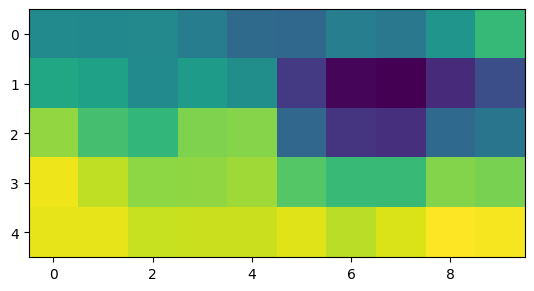

In [15]:
print(lfw_people.images[0][20:25,25:35])
plt.imshow(lfw_people.images[0][20:25,25:35])
plt.show()

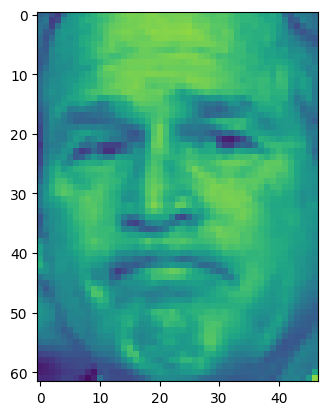

In [16]:
plt.imshow(lfw_people.images[0], vmin=0, vmax=1)
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
X = lfw_people.data         # 이미지 데이터 (flattened)
y = lfw_people.target       # 정수 레이블
target_names = lfw_people.target_names  # 이름

# train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 결과 출력
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Target classes:", target_names)

Train shape: (855, 2914) (855,)
Test shape: (285, 2914) (285,)
Target classes: ['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']


In [20]:
# 1. softmax, categorical crossentropy 사용할 거니까 output 정수로 변환하고, 원핫 인코딩 진행하기
# 문자열 레이블을 정수로 변환
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)  # 문자열 → 정수
y_test_int = le.transform(y_test)

# 정수 레이블 → 원-핫 인코딩
y_train_encoded = to_categorical(y_train_int)
y_test_encoded = to_categorical(y_test_int)

# 스케일러 적용하기, standardscaler, minmax scaler 중에서 standardscaler를 사용하는 게 더 좋을듯
scaler = StandardScaler()
scaler.fit(X_train)
x_train_zs = scaler.transform(X_train)
x_test_zs = scaler.transform(X_test)
print(x_train_zs.shape, y_test.shape)

(855, 2914) (285,)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 2048)           │     5,969,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,028,613 (34.44 MB)

 Trainable params: 9,028,613 (34.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.3947 - loss: 1.5541 - val_accuracy: 0.5754 - val_loss: 1.0691
Epoch 2/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6277 - loss: 0.9747 - val_accuracy: 0.6596 - val_loss: 0.8800
Epoch 3/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7178 - loss: 0.7440 - val_accuracy: 0.7018 - val_loss: 0.8729
Epoch 4/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7434 - loss: 0.6253 - val_accuracy: 0.7333 - val_loss: 0.7601
Epoch 5/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8538 - loss: 0.4168 - val_accuracy: 0.8105 - val_loss: 0.5241
Epoch 6/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8875 - loss: 0.3110 - val_accuracy: 0.8175 - val_loss: 0.5881
Epoch 7/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8980 - loss: 0.3116 - val_accuracy: 0.7895 - val_loss: 0.6763
Epoch 8/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9024 - loss: 0.3337 - val_accuracy: 0.8421 - v

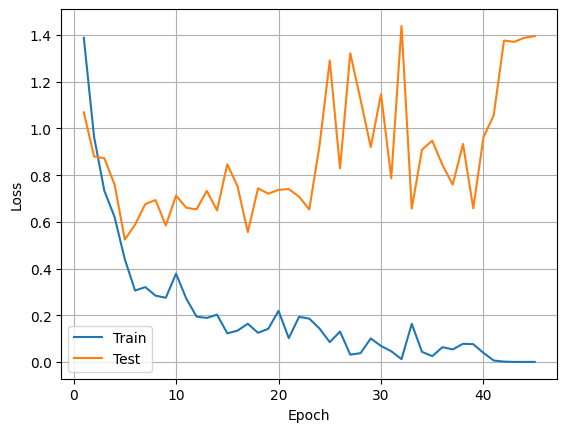

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt

# MLP 모델 학습
# 그래프 시각화
bc_nn = Sequential()
bc_nn.add(Input(shape=(2914,)))
bc_nn.add(Dense(2048, activation='relu'))
bc_nn.add(Dense(1024, activation='relu'))
bc_nn.add(Dense(512, activation='relu'))
bc_nn.add(Dense(256, activation='relu'))
bc_nn.add(Dense(512, activation='relu'))
bc_nn.add(Dense(256, activation='relu'))
bc_nn.add(Dense(128, activation='relu'))
bc_nn.add(Dense(64, activation='relu'))
bc_nn.add(Dense(5, activation='softmax'))
bc_nn.summary()
bc_nn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = bc_nn.fit(x_train_zs, y_train_encoded,
                 validation_data=(x_test_zs, y_test_encoded),
                 epochs=45)

plt.plot(range(1,46), hist.history['loss'], label='Train')
plt.plot(range(1,46), hist.history['val_loss'], label='Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()    # 격자무늬 설정
plt.legend()  # 범례 표시
plt.show()